# Assignment 2 — Encoding & Transformation Impact

**Course:** Feature Engineering & MLOps  
**Topic:** One-Hot Encoding (2.1) + Transformations & Model Comparison (2.2)

### Objectives

- **Part 2.1:** One-hot encode `city`, `course`, and `batch_type` using train-only fitting.
- **Part 2.2:** Transform the right-skewed `weekly_study_hours` feature and compare Linear Regression and Decision Tree Regressor before vs. after transformation.
- Use the **80/20 split**, random seed, predictors, and model settings for a fair comparison.
- Report **R² and RMSE**, visualize the R² comparison, and explain why linear and tree models respond differently.
- Include the **optional KNN bonus** as an additional distance-based comparison.

The dataset `student_performance_raw.csv` is used.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
candidate_paths = [
    Path("../data/raw/student_performance_raw.csv"),
    Path("data/raw/student_performance_raw.csv"),
    Path("student_performance_raw.csv"),
    Path("/mnt/data/student_performance_raw.csv"),
]

DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("student_performance_raw.csv was not found in the expected locations.")

df = pd.read_csv(DATA_PATH)

print(f"Dataset path: {DATA_PATH}")
print(f"Shape: {df.shape}")
display(df.head())


Dataset path: student_performance_raw.csv
Shape: (600, 17)


,student_id,city,city_tier,course,batch_type,age,enrollment_date,attendance_pct,weekly_study_hours,income_bracket,prev_exam_score,mock_test_1,mock_test_2,mock_test_3,doubt_sessions_attended,feedback_text,final_score
0,1447,Patna,2,JEE Main,Weekday,18,2026-05-27,91.1,0.8,<5L,65.2,68.1,59.0,72.2,1,Need more practice sheets for weak topics,42.0
1,1405,Patna,2,NEET,Weekday,16,2024-07-08,91.9,2.4,NaN,64.9,82.0,88.4,100.0,3,Would like more one-on-one mentoring,62.0
2,1510,Mumbai,1,JEE Main,Weekday,18,2025-03-17,67.1,6.7,5-10L,90.1,86.5,91.1,76.4,5,"Great teaching pace, doubts cleared quickly",56.4
3,1456,Delhi,1,NEET,Weekday,18,2025-06-16,70.7,2.0,10-20L,29.7,19.4,24.9,NaN,3,Need more practice sheets for weak topics,31.7
4,1202,Patna,2,JEE Advanced,Weekday,17,2026-04-16,69.3,6.5,>20L,70.0,63.8,74.5,69.1,4,Need more practice sheets for weak topics,44.5


## 1. Dataset Inspection

The assignment identifies:

- `city`, `course`, `batch_type` → nominal categorical variables for encoding.
- `weekly_study_hours` → skewed numeric feature to transform.
- `attendance_pct`, `prev_exam_score`, `doubt_sessions_attended` → additional numeric predictors that remain unchanged.
- `final_score` → continuous regression target.

`weekly_study_hours` and `prev_exam_score` contain missing values, so their imputation must use statistics learned from the training data only.


In [2]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nUnique values in categorical assignment columns:")
for col in ["city", "course", "batch_type"]:
    print(f"{col}: {df[col].nunique(dropna=True)} unique categories")
    print(sorted(df[col].dropna().unique().tolist()))
    print()


Columns:
['student_id', 'city', 'city_tier', 'course', 'batch_type', 'age', 'enrollment_date', 'attendance_pct', 'weekly_study_hours', 'income_bracket', 'prev_exam_score', 'mock_test_1', 'mock_test_2', 'mock_test_3', 'doubt_sessions_attended', 'feedback_text', 'final_score']

Data types:


,dtype
student_id,int64
city,object
city_tier,int64
course,object
batch_type,object
age,int64
enrollment_date,object
attendance_pct,float64
weekly_study_hours,float64
income_bracket,object



Missing values:


,missing_count
feedback_text,68
weekly_study_hours,36
income_bracket,30
prev_exam_score,25
mock_test_3,21
student_id,0
city,0
course,0
city_tier,0
attendance_pct,0



Unique values in categorical assignment columns:
city: 8 unique categories
['Bengaluru', 'Delhi', 'Hyderabad', 'Kota', 'Lucknow', 'Mumbai', 'Patna', 'Pune']

course: 4 unique categories
['Foundation', 'JEE Advanced', 'JEE Main', 'NEET']

batch_type: 3 unique categories
['Crash Course', 'Weekday', 'Weekend']



## 2. Train/Test Split

A single fixed split is created **once** and reused for every required experiment. This is essential for a fair before/after comparison: the rows in train and test must not change when `weekly_study_hours` is transformed.

The two columns with missing values are imputed **after the split**, using statistics fitted only on `X_train`. 

In [3]:
target = "final_score"

categorical_cols = ["city", "course", "batch_type"]
numeric_predictors = [
    "weekly_study_hours",
    "attendance_pct",
    "prev_exam_score",
    "doubt_sessions_attended",
]

X = df[categorical_cols + numeric_predictors].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows:  {len(X_test)}")
print(f"Training proportion: {len(X_train)/len(X):.0%}")
print(f"Testing proportion:  {len(X_test)/len(X):.0%}")

# Training-only imputation for the two columns named in the assignment.
impute_cols = ["weekly_study_hours", "prev_exam_score"]
imputer = SimpleImputer(strategy="median")

X_train = X_train.copy()
X_test = X_test.copy()

X_train[impute_cols] = imputer.fit_transform(X_train[impute_cols])
X_test[impute_cols] = imputer.transform(X_test[impute_cols])

print("\nTraining-only imputation statistics:")
display(pd.Series(imputer.statistics_, index=impute_cols, name="training_median"))

assert X_train[impute_cols].isna().sum().sum() == 0
assert X_test[impute_cols].isna().sum().sum() == 0
print("✓ No missing values remain in the required numeric predictors.")


Training rows: 480
Testing rows:  120
Training proportion: 80%
Testing proportion:  20%

Training-only imputation statistics:


weekly_study_hours     5.0
prev_exam_score       66.1
Name: training_median, dtype: float64

✓ No missing values remain in the required numeric predictors.


## Part 2.1 — One-Hot Encoding

`city`, `course`, and `batch_type` are **nominal** because their category labels do not have a meaningful natural ranking. Therefore, one-hot encoding is appropriate rather than ordinal/label encoding.


In [4]:
# Fit the encoder on TRAINING categorical columns only.
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

encoded_feature_names = encoder.get_feature_names_out(categorical_cols)

print(f"Categorical columns before encoding: {len(categorical_cols)}")
print(f"One-hot columns after encoding: {len(encoded_feature_names)}")

display(pd.DataFrame(
    X_train_cat,
    columns=encoded_feature_names,
    index=X_train.index
).head())

print("\nEncoder categories learned from training data:")
for col, cats in zip(categorical_cols, encoder.categories_):
    print(f"{col}: {list(cats)}")


Categorical columns before encoding: 3
One-hot columns after encoding: 15


,city_Bengaluru,city_Delhi,city_Hyderabad,city_Kota,city_Lucknow,city_Mumbai,city_Patna,city_Pune,course_Foundation,course_JEE Advanced,course_JEE Main,course_NEET,batch_type_Crash Course,batch_type_Weekday,batch_type_Weekend
145,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
9,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
375,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
523,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
188,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0



Encoder categories learned from training data:
city: ['Bengaluru', 'Delhi', 'Hyderabad', 'Kota', 'Lucknow', 'Mumbai', 'Patna', 'Pune']
course: ['Foundation', 'JEE Advanced', 'JEE Main', 'NEET']
batch_type: ['Crash Course', 'Weekday', 'Weekend']


In [5]:
# Dimensionality of the actual modeling dataset before and after one-hot encoding.
# Four numeric predictors are retained in both versions.
features_before_count = len(numeric_predictors) + len(categorical_cols)
features_after_count = len(numeric_predictors) + len(encoded_feature_names)

dimensionality_table = pd.DataFrame({
    "Stage": ["Before one-hot encoding", "After one-hot encoding"],
    "Numeric predictors": [len(numeric_predictors), len(numeric_predictors)],
    "Categorical representation": [len(categorical_cols), len(encoded_feature_names)],
    "Total model features": [features_before_count, features_after_count]
})

display(dimensionality_table)

increase = features_after_count - features_before_count
print(
    f"One-hot encoding increases the model feature count from "
    f"{features_before_count} to {features_after_count}, an increase of {increase} columns."
)


,Stage,Numeric predictors,Categorical representation,Total model features
0,Before one-hot encoding,4,3,7
1,After one-hot encoding,4,15,19


One-hot encoding increases the model feature count from 7 to 19, an increase of 12 columns.


In [6]:
# Check whether any category appears in test but not in training.
test_only_categories = {}

for col in categorical_cols:
    train_categories = set(X_train[col].dropna().unique())
    test_categories = set(X_test[col].dropna().unique())
    only_in_test = sorted(test_categories - train_categories)
    test_only_categories[col] = only_in_test

test_only_table = pd.DataFrame({
    "column": categorical_cols,
    "categories_only_in_test": [test_only_categories[c] for c in categorical_cols],
    "count": [len(test_only_categories[c]) for c in categorical_cols]
})

display(test_only_table)

# This transformation must succeed even if a category is test-only.
assert X_test_cat.shape[0] == len(X_test)
print(
    "✓ Test transformation completed successfully with handle_unknown='ignore'. "
    "Any unseen test category would therefore produce zeros for the learned one-hot columns "
    "instead of raising an error."
)


,column,categories_only_in_test,count
0,city,[],0
1,course,[],0
2,batch_type,[],0


✓ Test transformation completed successfully with handle_unknown='ignore'. Any unseen test category would therefore produce zeros for the learned one-hot columns instead of raising an error.


## Build the Common Modeling Feature Matrix

For the before/after experiment, the only representation that changes is `weekly_study_hours`.

The common predictors are:

1. `weekly_study_hours` — raw or transformed depending on the version.
2. `attendance_pct` — unchanged.
3. `prev_exam_score` — unchanged after training-only imputation.
4. `doubt_sessions_attended` — unchanged.
5. All one-hot encoded `city`, `course`, and `batch_type` columns — identical in both versions.

No other feature is changed.


In [7]:
# Reconstruct encoded matrices as DataFrames so column alignment is explicit.
train_cat_df = pd.DataFrame(
    X_train_cat, columns=encoded_feature_names, index=X_train.index
)
test_cat_df = pd.DataFrame(
    X_test_cat, columns=encoded_feature_names, index=X_test.index
)

other_numeric = ["attendance_pct", "prev_exam_score", "doubt_sessions_attended"]

X_train_common = pd.concat(
    [X_train[["weekly_study_hours"] + other_numeric], train_cat_df],
    axis=1
)
X_test_common = pd.concat(
    [X_test[["weekly_study_hours"] + other_numeric], test_cat_df],
    axis=1
)

print("Common feature matrix shape:")
print("Train:", X_train_common.shape)
print("Test: ", X_test_common.shape)

assert list(X_train_common.columns) == list(X_test_common.columns)
assert X_train_common.isna().sum().sum() == 0
assert X_test_common.isna().sum().sum() == 0


Common feature matrix shape:
Train: (480, 19)
Test:  (120, 19)


## Part 2.2 — Diagnose Skewness


,Feature,Training skewness,Training minimum,Training maximum
0,weekly_study_hours,1.595727,0.2,31.4


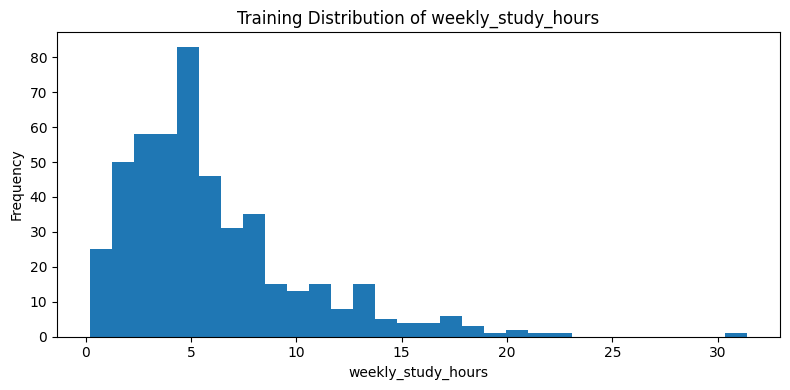

Observed skewness = 1.5957 → strong right skew.


In [8]:
weekly_skewness = X_train_common["weekly_study_hours"].skew()

skewness_table = pd.DataFrame({
    "Feature": ["weekly_study_hours"],
    "Training skewness": [weekly_skewness],
    "Training minimum": [X_train_common["weekly_study_hours"].min()],
    "Training maximum": [X_train_common["weekly_study_hours"].max()]
})

display(skewness_table)

plt.figure(figsize=(8, 4))
plt.hist(X_train_common["weekly_study_hours"], bins=30)
plt.xlabel("weekly_study_hours")
plt.ylabel("Frequency")
plt.title("Training Distribution of weekly_study_hours")
plt.tight_layout()
plt.show()

if weekly_skewness > 1:
    interpretation = "strong right skew"
elif weekly_skewness > 0.5:
    interpretation = "moderate right skew"
elif weekly_skewness > 0:
    interpretation = "mild right skew"
else:
    interpretation = "not right-skewed"

print(f"Observed skewness = {weekly_skewness:.4f} → {interpretation}.")


### Transformation Choice: `np.log1p`

 **log transformation using `np.log1p(x)`**.

The supplied feature is non-negative (including after training-only median imputation), so a log-based transformation is valid. `log1p(x)` is preferable to `log(x)` here because it safely handles a value of zero. The purpose is to compress the long right tail and make the feature's distribution less skewed while preserving its ordering.


,Version,weekly_study_hours skewness,minimum,maximum
0,Before,1.595727,0.200000,31.400000
1,After,-0.039165,0.182322,3.478158


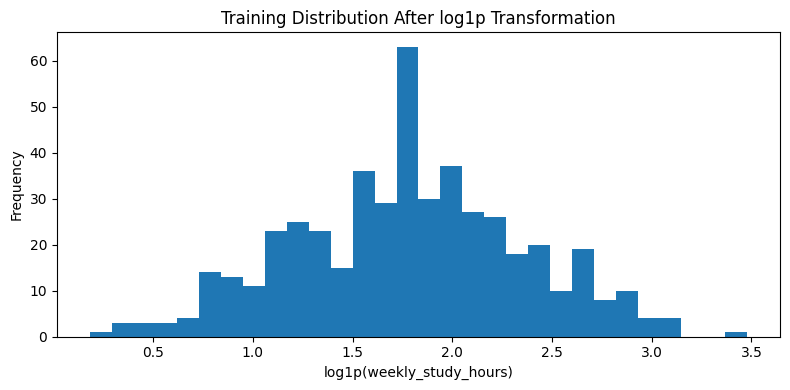

Skewness changed from 1.5957 to -0.0392, showing the effect of the transformation.


In [9]:
# Apply the selected transformation using the already-imputed values.
X_train_before = X_train_common.copy()
X_test_before = X_test_common.copy()

X_train_after = X_train_common.copy()
X_test_after = X_test_common.copy()

X_train_after["weekly_study_hours"] = np.log1p(
    X_train_after["weekly_study_hours"]
)
X_test_after["weekly_study_hours"] = np.log1p(
    X_test_after["weekly_study_hours"]
)

before_skew = X_train_before["weekly_study_hours"].skew()
after_skew = X_train_after["weekly_study_hours"].skew()

transformation_summary = pd.DataFrame({
    "Version": ["Before", "After"],
    "weekly_study_hours skewness": [before_skew, after_skew],
    "minimum": [
        X_train_before["weekly_study_hours"].min(),
        X_train_after["weekly_study_hours"].min()
    ],
    "maximum": [
        X_train_before["weekly_study_hours"].max(),
        X_train_after["weekly_study_hours"].max()
    ]
})

display(transformation_summary)

plt.figure(figsize=(8, 4))
plt.hist(X_train_after["weekly_study_hours"], bins=30)
plt.xlabel("log1p(weekly_study_hours)")
plt.ylabel("Frequency")
plt.title("Training Distribution After log1p Transformation")
plt.tight_layout()
plt.show()

print(
    f"Skewness changed from {before_skew:.4f} to {after_skew:.4f}, "
    f"showing the effect of the transformation."
)


## Four Required Model Runs

The same train/test rows are used for all four required models.

| Model | Feature version | Role |
|---|---|---|
| Linear Regression | Before | Baseline |
| Linear Regression | After | Test transformation effect |
| Decision Tree Regressor | Before | Baseline |
| Decision Tree Regressor | After | Test transformation effect |

For the Decision Tree, `random_state` and `max_depth` are explicitly fixed and identical in both runs, as required.


In [10]:
def evaluate_regressor(model, X_train_model, X_test_model, y_train_model, y_test_model):
    """Fit a regressor and return its test-set R2 and RMSE."""
    model.fit(X_train_model, y_train_model)
    predictions = model.predict(X_test_model)
    return {
        "R2": r2_score(y_test_model, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test_model, predictions)),
        "model_object": model,
    }

tree_random_state = 42
tree_max_depth = 6

results = []

# 1. Linear Regression — Before
lr_before = LinearRegression()
metrics = evaluate_regressor(
    lr_before, X_train_before, X_test_before, y_train, y_test
)
results.append({
    "Model": "Linear Regression",
    "Version": "Before",
    "R2": metrics["R2"],
    "RMSE": metrics["RMSE"],
})

# 2. Linear Regression — After
lr_after = LinearRegression()
metrics = evaluate_regressor(
    lr_after, X_train_after, X_test_after, y_train, y_test
)
results.append({
    "Model": "Linear Regression",
    "Version": "After",
    "R2": metrics["R2"],
    "RMSE": metrics["RMSE"],
})

# 3. Decision Tree — Before
dt_before = DecisionTreeRegressor(
    random_state=tree_random_state,
    max_depth=tree_max_depth
)
metrics = evaluate_regressor(
    dt_before, X_train_before, X_test_before, y_train, y_test
)
results.append({
    "Model": "Decision Tree Regressor",
    "Version": "Before",
    "R2": metrics["R2"],
    "RMSE": metrics["RMSE"],
})

# 4. Decision Tree — After
dt_after = DecisionTreeRegressor(
    random_state=tree_random_state,
    max_depth=tree_max_depth
)
metrics = evaluate_regressor(
    dt_after, X_train_after, X_test_after, y_train, y_test
)
results.append({
    "Model": "Decision Tree Regressor",
    "Version": "After",
    "R2": metrics["R2"],
    "RMSE": metrics["RMSE"],
})

results_df = pd.DataFrame(results)

# Model-level comparison deltas.
results_df["R2_change_vs_before"] = results_df.groupby("Model")["R2"].transform(
    lambda s: s - s.iloc[0]
)
results_df["RMSE_change_vs_before"] = results_df.groupby("Model")["RMSE"].transform(
    lambda s: s - s.iloc[0]
)

display(results_df[[
    "Model", "Version", "R2", "RMSE",
    "R2_change_vs_before", "RMSE_change_vs_before"
]])

assert len(results_df) == 4


,Model,Version,R2,RMSE,R2_change_vs_before,RMSE_change_vs_before
0,Linear Regression,Before,0.592997,6.391525,0.000000,0.000000
1,Linear Regression,After,0.573414,6.543488,-0.019584,0.151962
2,Decision Tree Regressor,Before,0.434791,7.532002,0.000000,0.000000
3,Decision Tree Regressor,After,0.434791,7.532002,0.000000,0.000000


## R² Comparison

The chart below visualizes all four required runs so the before/after pattern can be assessed at a glance.


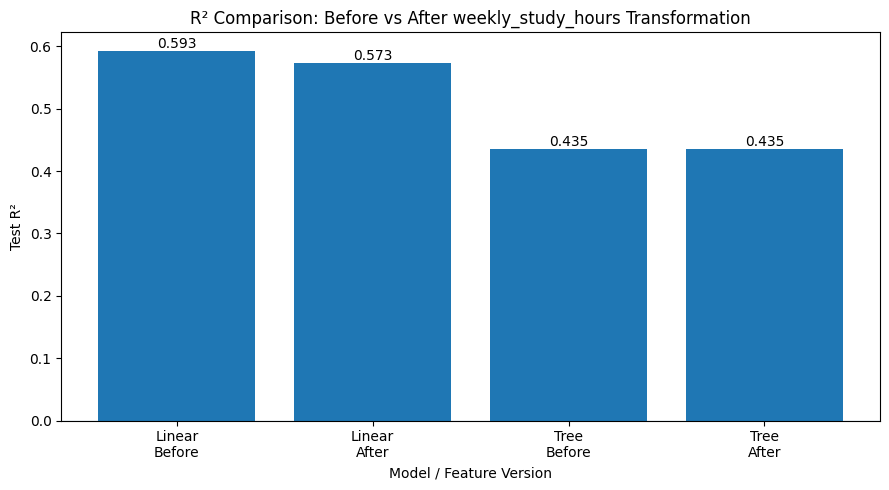

In [11]:
plot_labels = [
    "Linear\nBefore",
    "Linear\nAfter",
    "Tree\nBefore",
    "Tree\nAfter",
]
r2_values = results_df["R2"].tolist()

plt.figure(figsize=(9, 5))
bars = plt.bar(plot_labels, r2_values)
plt.ylabel("Test R²")
plt.xlabel("Model / Feature Version")
plt.title("R² Comparison: Before vs After weekly_study_hours Transformation")
plt.axhline(0, linewidth=0.8)

for bar, value in zip(bars, r2_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


In [12]:
# Compact comparison table exactly in the requested model × version × metric form.
summary_table = results_df[["Model", "Version", "R2", "RMSE"]].copy()
display(summary_table)

# Extract changes for interpretation.
lr_before_r2 = results_df.query("Model == 'Linear Regression' and Version == 'Before'")["R2"].iloc[0]
lr_after_r2 = results_df.query("Model == 'Linear Regression' and Version == 'After'")["R2"].iloc[0]
lr_before_rmse = results_df.query("Model == 'Linear Regression' and Version == 'Before'")["RMSE"].iloc[0]
lr_after_rmse = results_df.query("Model == 'Linear Regression' and Version == 'After'")["RMSE"].iloc[0]

dt_before_r2 = results_df.query("Model == 'Decision Tree Regressor' and Version == 'Before'")["R2"].iloc[0]
dt_after_r2 = results_df.query("Model == 'Decision Tree Regressor' and Version == 'After'")["R2"].iloc[0]
dt_before_rmse = results_df.query("Model == 'Decision Tree Regressor' and Version == 'Before'")["RMSE"].iloc[0]
dt_after_rmse = results_df.query("Model == 'Decision Tree Regressor' and Version == 'After'")["RMSE"].iloc[0]

print(f"Linear Regression: ΔR² = {lr_after_r2 - lr_before_r2:+.6f}; ΔRMSE = {lr_after_rmse - lr_before_rmse:+.6f}")
print(f"Decision Tree:     ΔR² = {dt_after_r2 - dt_before_r2:+.6f}; ΔRMSE = {dt_after_rmse - dt_before_rmse:+.6f}")


,Model,Version,R2,RMSE
0,Linear Regression,Before,0.592997,6.391525
1,Linear Regression,After,0.573414,6.543488
2,Decision Tree Regressor,Before,0.434791,7.532002
3,Decision Tree Regressor,After,0.434791,7.532002


Linear Regression: ΔR² = -0.019584; ΔRMSE = +0.151962
Decision Tree:     ΔR² = +0.000000; ΔRMSE = +0.000000


## Conclusion

The results show that the transformation affected the two model types differently. For Linear Regression, performance changed after applying the log1p transformation: the R² decreased from 0.592997 to 0.573414, while the RMSE increased from 6.391525 to 6.543488. Linear Regression uses the actual numerical values of features to learn coefficients and minimize prediction errors, so changing weekly_study_hours from its raw values to a logarithmic scale changed the relationship the model could represent between this feature and final_score. Although the transformation successfully reduced skewness, it did not improve the linear relationship with the target in this dataset, resulting in slightly worse performance.

In contrast, the Decision Tree Regressor’s performance remained exactly the same, with an R² of 0.434791 and RMSE of 7.532002 before and after transformation. A Decision Tree does not use feature values through coefficients or gradient-based optimization; instead, it makes predictions by finding threshold-based splits such as whether weekly_study_hours < threshold. Since log1p is a monotonic transformation, it preserves the ordering of observations, so the tree can create equivalent threshold splits after transformation and separate the same data points. Therefore, the transformation changed the numerical scale of the feature enough to affect Linear Regression, but had virtually no effect on the Decision Tree’s threshold-based decision process.

## Optional Bonus — K-Nearest Neighbors Regressor

Unlike the tree, KNN is genuinely distance-based: it identifies nearby rows using distances between feature vectors. A skewed feature can therefore have a stronger influence on distances when its raw numerical representation has a long tail.

To make the KNN comparison meaningful, a `StandardScaler` is fitted separately within each before/after pipeline using **training data only**. The same KNN settings are used in both runs; only the representation of `weekly_study_hours` changes.


In [13]:
# KNN bonus.
# Scaling is fit on training data only and keeps the before/after KNN experiment fair.
knn_before = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=5))
])

knn_after = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=5))
])

knn_results = []

for version, model, Xtr, Xte in [
    ("Before", knn_before, X_train_before, X_test_before),
    ("After", knn_after, X_train_after, X_test_after),
]:
    metrics = evaluate_regressor(model, Xtr, Xte, y_train, y_test)
    knn_results.append({
        "Model": "KNN Regressor",
        "Version": version,
        "R2": metrics["R2"],
        "RMSE": metrics["RMSE"],
    })

knn_df = pd.DataFrame(knn_results)
display(knn_df)

knn_r2_change = (
    knn_df.loc[knn_df["Version"] == "After", "R2"].iloc[0]
    - knn_df.loc[knn_df["Version"] == "Before", "R2"].iloc[0]
)
knn_rmse_change = (
    knn_df.loc[knn_df["Version"] == "After", "RMSE"].iloc[0]
    - knn_df.loc[knn_df["Version"] == "Before", "RMSE"].iloc[0]
)

print(f"KNN ΔR² = {knn_r2_change:+.6f}")
print(f"KNN ΔRMSE = {knn_rmse_change:+.6f}")


,Model,Version,R2,RMSE
0,KNN Regressor,Before,-0.013978,10.088349
1,KNN Regressor,After,-0.013912,10.088020


KNN ΔR² = +0.000066
KNN ΔRMSE = -0.000329


### KNN Interpretation

KNN did not show an even larger improvement from the transformation than Linear Regression. KNN’s performance improved only very slightly after the log1p transformation: R² increased from -0.013978 to -0.013912 (ΔR² = +0.000066) and RMSE decreased from 10.088349 to 10.088020 (ΔRMSE = -0.000329). In comparison, Linear Regression’s performance changed more noticeably, although it actually became worse after transformation, with R² decreasing by 0.019584 and RMSE increasing by 0.151962.

KNN makes predictions by computing distances between rows and averaging the target values of the nearest neighbours. Therefore, changing the scale or distribution of weekly_study_hours can affect the distances between observations and potentially change which rows are selected as nearest neighbours. However, in this experiment, weekly_study_hours was only one feature among several predictors, and the StandardScaler already standardized the features before KNN calculated distances. As a result, the log1p transformation produced only a negligible change in the distances and therefore only a negligible improvement in KNN performance.
